In [1]:
import keras
import numpy as np
import torchvision

# MNIST dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                          train=False,
                                          transform=transform)

X_train = train_dataset.data
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

train = X_train, y_train_cat
test = X_test, y_test_cat

print(f"Размер тренировочных данных: {X_train.shape}")
print(f"Размер тестовых данных: {X_test.shape}")
print(f"Метки классов: {np.unique(y_train)}")


/home/zab/Git/ML_Course_PT/Hometasks/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Размер тренировочных данных: (50000, 32, 32, 3)
Размер тестовых данных: (10000, 32, 32, 3)
Метки классов: [0 1 2 3 4 5 6 7 8 9]


In [2]:
from matplotlib import pyplot as plt

def train_and_evaluate_model(model, train, test, epochs=10, batch_size=32):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    X_train, y_train_cat = train
    X_test, y_test_cat = test


    history = model.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\nТестовая точность: {test_accuracy:.4f}")
    print(f"Тестовая потеря: {test_loss:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].set_title('Точность модели')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Точность')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].set_title('Потери модели')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Потери')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return model


I0000 00:00:1773448137.625594 2019864 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11912 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0
I0000 00:00:1773448137.627977 2019864 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4564 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:03:00.0, compute capability: 7.5


Epoch 1/10


2026-03-14 03:28:58.762366: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f148c005570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 03:28:58.762380: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-03-14 03:28:58.762382: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-03-14 03:28:58.773838: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-14 03:28:58.836270: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-14 03:28:59.248817: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141',

 168/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.1609 - loss: 917.7786 

I0000 00:00:1773448140.183533 2019933 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1533/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.1704 - loss: 203.6171

2026-03-14 03:29:01.797306: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:02.147826: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 03:29:02.566195: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 140 bytes spill stores, 140 bytes spill loads

2026-03-14 03:29:02.605277: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 504 byte

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1371 - loss: 48.2141 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0984 - loss: 2.3171
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0967 - loss: 2.3033
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - accuracy: 0.0990 - loss: 2.3037
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.0997 - loss: 2.3082
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.0985 - loss: 2.3061
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - accuracy: 0.0986 - loss: 2.3026
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.1000 - loss: 2.3032
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 964us/step - accuracy: 0.0993 - loss: 2.3027
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - accuracy: 0.0981 - loss: 2.3027

Тестовая точность: 0.0999
Тестовая потеря: 2.3032


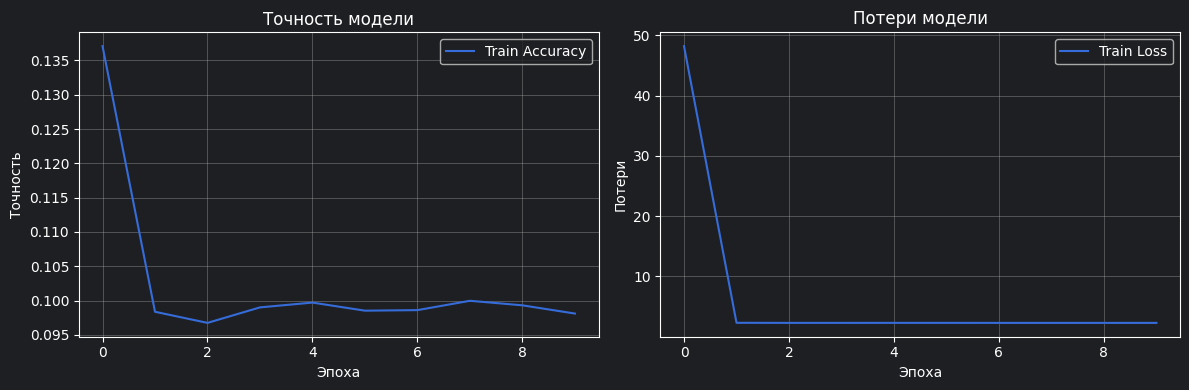

In [3]:
# TASK 1: baseline model but in tensorflow

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model(), train, test);

Epoch 1/10
1513/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1011 - loss: 46.8199

2026-03-14 03:29:22.591124: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:22.591144: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:22.591163: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:23.650114: I external/l

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0983 - loss: 10.0340
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0965 - loss: 2.3027
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0977 - loss: 2.3027
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0971 - loss: 2.3027
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0967 - loss: 2.3028
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0994 - loss: 2.3028  
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0991 - loss: 2.3028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0969 - loss: 2.3028
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0979 - loss: 2.3028  
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0987 - loss: 2.3028

Тестовая точность: 0.1000
Тестовая потеря: 2.3026


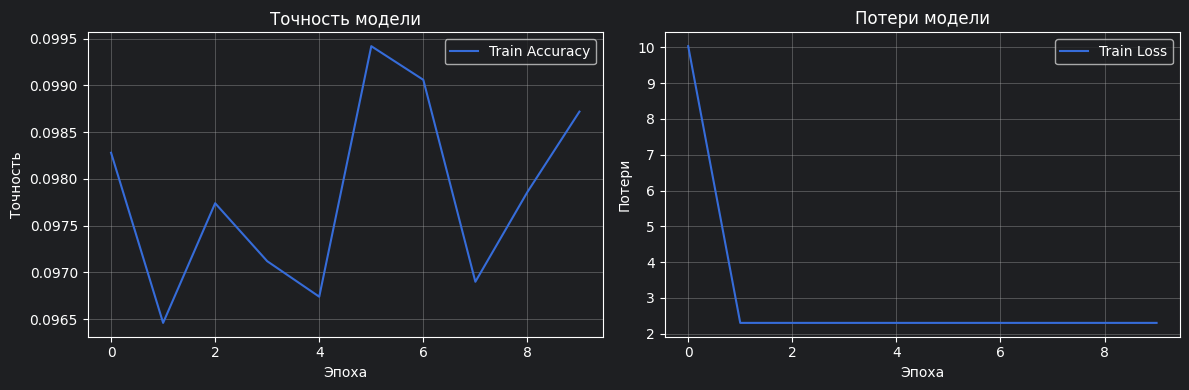

In [4]:
# TASK 2: additional dense layer

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    x = layers.Dense(100, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model(), train, test);

Epoch 1/10


2026-03-14 03:29:43.748156: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:43.748213: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:44.375558: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_298', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 03:29:44.747531: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

1535/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2278 - loss: 34.9237

2026-03-14 03:29:49.116289: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:29:50.074297: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_305', 88 bytes spill stores, 96 bytes spill loads

2026-03-14 03:29:50.763506: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_305', 4 bytes spill stores, 4 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2756 - loss: 8.6195
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3250 - loss: 1.8963
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3452 - loss: 1.8240
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3634 - loss: 1.7722
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3803 - loss: 1.7264
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3931 - loss: 1.6974
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3987 - loss: 1.6738
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4115 - loss: 1.6489
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4170 - loss: 1.6331
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4239 - loss: 1.6098

Тестовая точность: 0.4073
Тестовая потеря: 1.6676


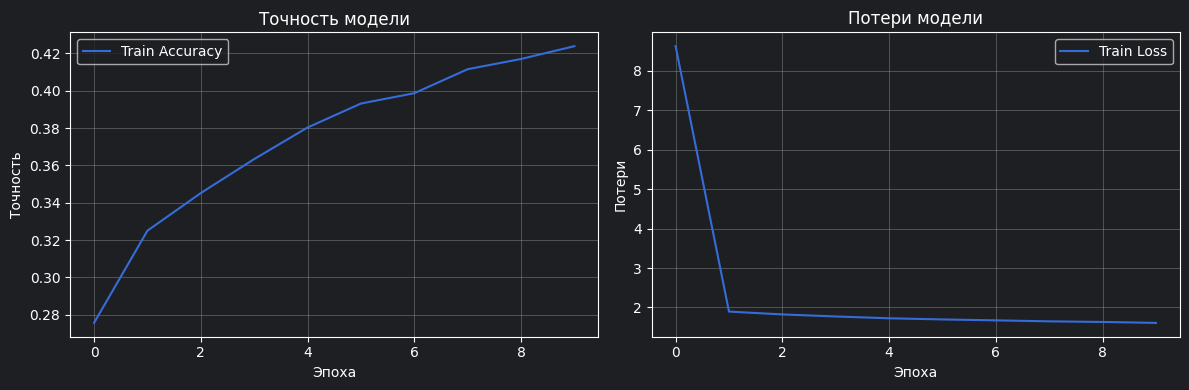

In [5]:
# TASK 3: more additional dense layers

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model(), train, test);

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1331 - loss: 5.5142 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1570 - loss: 2.1747
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1553 - loss: 2.1682
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1629 - loss: 2.1612
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1615 - loss: 2.1752
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1075 - loss: 2.3767
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1001 - loss: 2.3010
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0983 - loss: 2.3029
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0990 - loss: 2.3028
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0985 - loss: 2.3028

Тестовая точность: 0.1000
Тестовая потеря: 2.3026


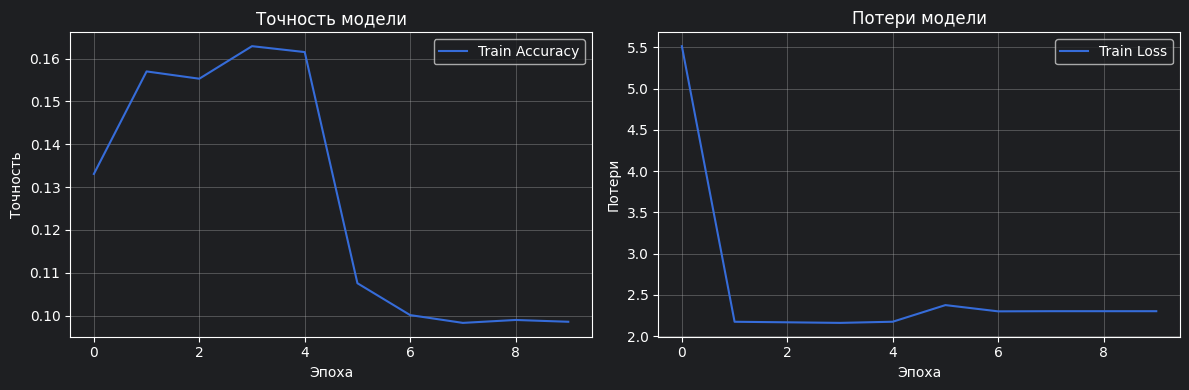

In [6]:
# TASK 4: dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model(), train, test);

Epoch 1/10


2026-03-14 03:30:43.121585: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 116 bytes spill stores, 116 bytes spill loads

2026-03-14 03:30:43.197420: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 776 bytes spill stores, 772 bytes spill loads



1548/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3280 - loss: 1.8681

2026-03-14 03:30:47.033071: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 12 bytes spill stores, 12 bytes spill loads

2026-03-14 03:30:47.212747: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 776 bytes spill stores, 772 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3765 - loss: 1.7398
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4531 - loss: 1.5312
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4916 - loss: 1.4241
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5224 - loss: 1.3402
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5503 - loss: 1.2610
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5729 - loss: 1.2029
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5921 - loss: 1.1452
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6167 - loss: 1.0804
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6380 - loss: 1.0216
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6561 - loss: 0.9681


2026-03-14 03:31:06.774952: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_100', 1044 bytes spill stores, 1028 bytes spill loads




Тестовая точность: 0.5512
Тестовая потеря: 1.3187


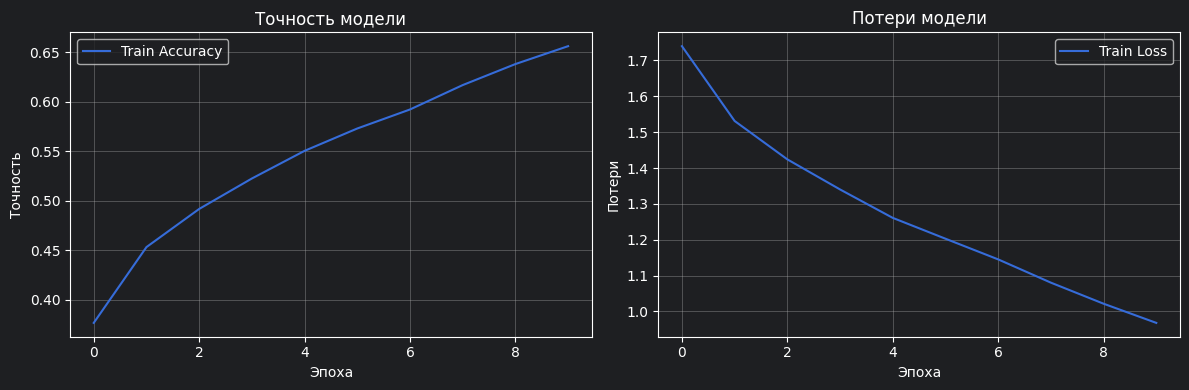

In [7]:
# TASK 5: batch normalization instead of dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model(), train, test);

2026-03-14 03:31:08.927058: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 03:31:09.957670: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_82', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 03:31:09.972878: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_82', 88 bytes spill stores, 96 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


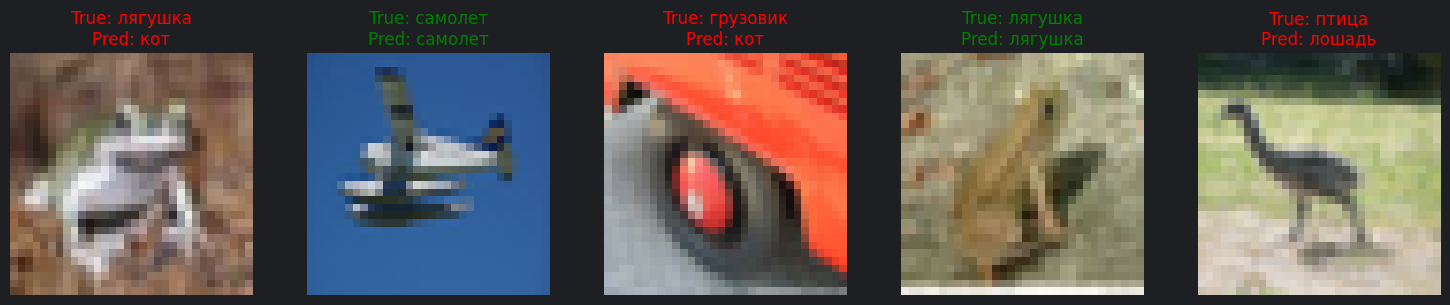

In [8]:
class_names = ['самолет', 'автомобиль', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Функция для визуализации предсказаний
def show_predictions(model, x_test, y_test, num_images=5):
    indices = np.random.choice(len(x_test), num_images, replace=False)

    predictions = model.predict(x_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = y_test[indices]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(indices):
        axes[i].imshow(x_test[idx])
        axes[i].axis('off')

        color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
        title = f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}"
        axes[i].set_title(title, color=color)

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)